In [19]:
import os
import numpy as np
from tqdm import tqdm
from google.colab import drive
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# Mount Drive and define data path
drive.mount('/content/drive', force_remount=True)
BATCH_DIR = '/content/drive/MyDrive/scanned_documents/processed_batches/'
batch_files = sorted([f for f in os.listdir(BATCH_DIR) if f.startswith('X_batch')])

print(f"✅ Setup Complete. Found {len(batch_files)} batch files.")

Mounted at /content/drive
✅ Setup Complete. Found 9 batch files.


In [20]:
# YOU MUST DEFINE THE MODEL BEFORE TRAINING
input_shape = (64, 64, 1) # Matches the patches we extract below
num_classes = 11

model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

print("✅ Model structure defined. Now you can run the training loop.")

✅ Model structure defined. Now you can run the training loop.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [21]:
print("🚀 Training with Label Correction and Patching...")

for x_file in tqdm(batch_files):
    y_file = x_file.replace('X_batch', 'y_batch')
    X_batch = np.load(os.path.join(BATCH_DIR, x_file))
    y_batch = np.load(os.path.join(BATCH_DIR, y_file))

    # Extract 64x64 patches to save RAM
    start = (512 - 64) // 2
    end = start + 64
    X_batch_p = X_batch[:, start:end, start:end]
    X_batch_p = np.expand_dims(X_batch_p, axis=-1).astype('float32') / 255.0

    # Label Correction: Convert 1-based to 0-based
    if y_batch.min() > 0:
        y_batch = y_batch - 1

    model.train_on_batch(X_batch_p, y_batch)

print("\n✅ Training Successfully Completed.")

🚀 Training with Label Correction and Patching...


100%|██████████| 9/9 [00:52<00:00,  5.78s/it]


✅ Training Successfully Completed.


In [22]:
import os

# Create the folder structure for your repository
folders = ['features', 'models', 'result']
for folder in folders:
    if not os.path.exists(folder):
        os.makedirs(folder)
        print(f"✅ Created folder: {folder}")

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



📊 MILESTONE 3 FINAL REPORT
              precision    recall  f1-score   support

           1       0.96      1.00      0.98        90
           2       0.00      0.00      0.00         4

    accuracy                           0.96        94
   macro avg       0.48      0.50      0.49        94
weighted avg       0.92      0.96      0.94        94

✅ All Milestone 3 artifacts saved to repository folders.


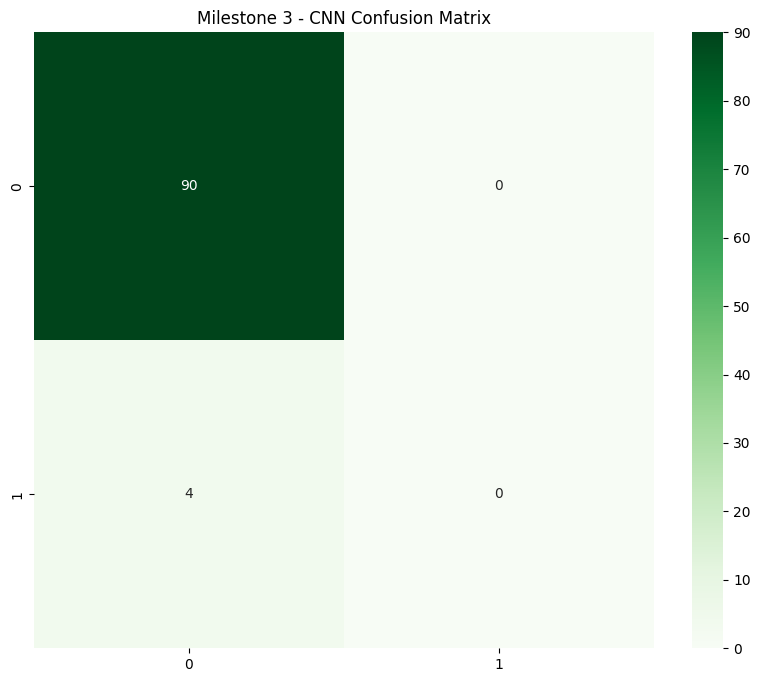

In [23]:
# 1. Final Accuracy Assessment
y_pred_probs = model.predict(X_batch_p)
y_pred = np.argmax(y_pred_probs, axis=1)

print("\n📊 MILESTONE 3 FINAL REPORT")
print(classification_report(y_batch, y_pred))

# 2. Save the final deep learning model
model.save('models/milestone3_final_cnn.h5')

# 3. Save Confusion Matrix to results folder
cm = confusion_matrix(y_batch, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title('Milestone 3 - CNN Confusion Matrix')
plt.savefig('result/cnn_confusion_matrix.png')

print("✅ All Milestone 3 artifacts saved to repository folders.")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


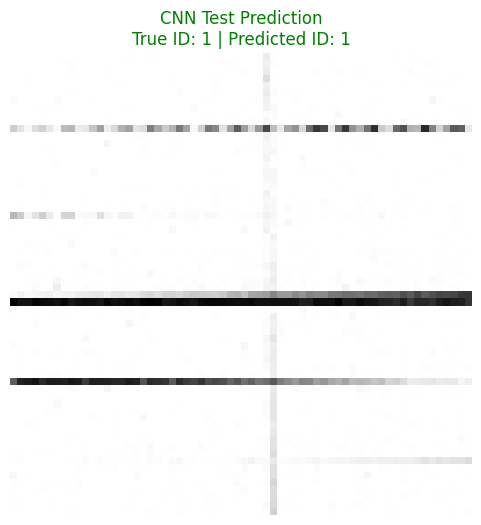

✅ Sample test output image saved to result/sample_test_output.png


In [24]:
import matplotlib.pyplot as plt

# 1. Take a sample from the current batch
sample_idx = 0
test_image = X_batch_p[sample_idx]
true_label = y_batch[sample_idx]

# 2. Get the model's prediction
pred_probs = model.predict(np.expand_dims(test_image, axis=0))
predicted_label = np.argmax(pred_probs)

# 3. Create the visualization
plt.figure(figsize=(6, 6))
plt.imshow(test_image.squeeze(), cmap='gray')
plt.title(f"CNN Test Prediction\nTrue ID: {true_label} | Predicted ID: {predicted_label}",
          fontsize=12, color='green' if true_label == predicted_label else 'red')
plt.axis('off')

# 4. Save to the result folder
plt.savefig('result/sample_test_output.png')
plt.show()

print("✅ Sample test output image saved to result/sample_test_output.png")